<a href="https://colab.research.google.com/github/jitesh0709/california-housing-price-prediction/blob/main/california_housing_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **California Housing Price Prediction**
**PIPELINE MINI PROJECT**

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


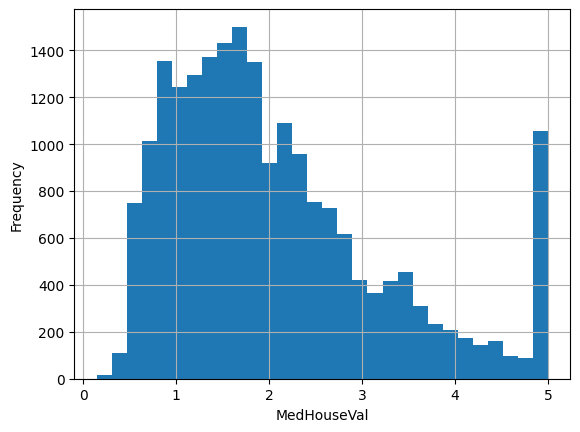

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(df.shape)
print(df.head())
print(df.isnull().sum())

import matplotlib.pyplot as plt

df['MedHouseVal'].hist(bins=30)
plt.xlabel('MedHouseVal')
plt.ylabel('Frequency')
plt.show()


### EDA

In [2]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
df.shape


(20640, 9)

In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
df.drop_duplicates()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [6]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


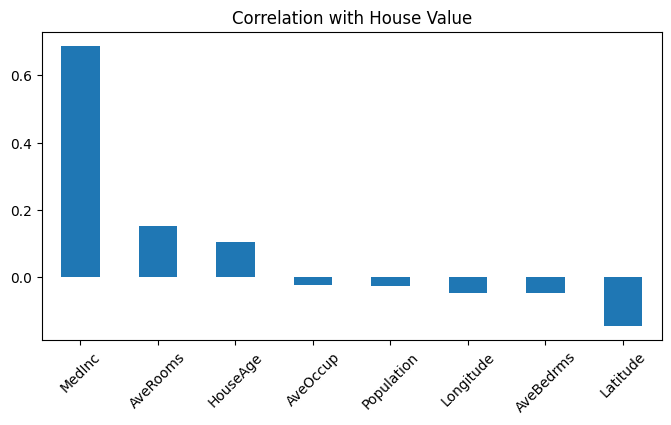

In [7]:
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlations)



import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
df.corr()['MedHouseVal'].sort_values(ascending=False).drop('MedHouseVal').plot(kind='bar')
plt.title('Correlation with House Value')
plt.xticks(rotation=45)
plt.show()

### Split

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


### Linear Regression  Pirpline

In [9]:
from sklearn import pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_pipe=Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr_pipe.fit(X_train, y_train)

print("linear regresssion", lr_pipe.score(X_test, y_test))

linear regresssion 0.575787706032451


### Random Forest Refressor

In [10]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
print("Random Forest Regressor", rf_pipeline.score(X_test, y_test))

Random Forest Regressor 0.8052747336256919


#### Evaluation MAE, RMSE

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
#get prediction from both model
lr_pred=lr_pipe.predict(X_test)
rf_pred=rf_pipeline.predict(X_test)

print("linear Regression:")
print("  MAE:", mean_absolute_error(y_test, lr_pred))
print("  RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("  R2:", r2_score(y_test, lr_pred))

print("\nRandom Forest Regression:")
print("  MAE:", mean_absolute_error(y_test, rf_pred))
print("  RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("  R2:", r2_score(y_test, rf_pred))

linear Regression:
  MAE: 0.5332001304956566
  RMSE: 0.7455813830127763
  R2: 0.575787706032451

Random Forest Regression:
  MAE: 0.3274252027374032
  RMSE: 0.5051432839771741
  R2: 0.8052747336256919


#### Tuning Random Forest

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [50,100],
    'model__max_depth': [None, 10, 20, 30]
}
grid = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("best cv", grid.best_score_)
print("test",grid.best_estimator_.score(X_test, y_test))

Best Parameters: {'model__max_depth': 20, 'model__n_estimators': 100}
best cv 0.8046253119705407
test 0.8048522204167272


#### Feature Importance

In [15]:
importances=grid.best_estimator_.named_steps['model'].feature_importances_
feature_names=X.columns

improtance_df=pd.DataFrame({
    'feature':feature_names,
    'importance':importances
})
improtance_df=improtance_df.sort_values('importance', ascending=False)

print(improtance_df)

      feature  importance
0      MedInc    0.525868
5    AveOccup    0.138544
6    Latitude    0.089032
7   Longitude    0.088480
1    HouseAge    0.054323
2    AveRooms    0.044099
4  Population    0.030322
3   AveBedrms    0.029333
